In [1]:
import os, shutil, pathlib, json
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import matplotlib.pyplot as plt
from absl import logging
import ml_collections
import optax

from typing import Any, Callable, Sequence, Optional, List, Tuple

import time
import wandb

from action_angle_networks import train, analysis
from action_angle_networks.simulation import harmonic_motion_simulation as hsim
from action_angle_networks.configs.harmonic_motion import default as hm_default

%config InlineBackend.figure_format = 'retina'
logging.set_verbosity(logging.INFO)

In [58]:
# Simulate 1d harmonic oscillator
#key = jax.random.PRNGKey(0)
# Simulate 1d harmonic oscillator

import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

@dataclass
class HarmonicParams:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    A_modes: np.ndarray   # (n,) amplitudes per normal mode
    phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def sample_harmonic_params(
    n: int,
    m_range: Tuple[float, float] = (1.0, 5.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,
    A_range: Tuple[float, float] = (1.0, 3.0),
    seed: Optional[int] = 0,
) -> HarmonicParams:
    rng = np.random.default_rng(seed)
    m = rng.uniform(*m_range, size=(n,)).astype(np.float64)
    # Normal-mode amplitudes/phases
    A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParams(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        A_modes=A_modes, phi_modes=phi_modes
    )

def _normal_mode_eigendecomposition(params: HarmonicParams):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_inv = np.diag(1.0 / params.m)
    M_inv_L = M_inv @ L
    eigvals, eigvecs = np.linalg.eig(M_inv_L)
    eigvals = eigvals.real
    eigvecs = eigvecs.real
    return eigvals, eigvecs  # (n,), (n,n)

def simulate_coupled_1d_harmonic(
    params: HarmonicParams, num_steps: int, dt: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = np.arange(num_steps, dtype=np.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = np.sqrt(np.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + params.phi_modes[None, :]  # (T, n)
    q_mode = params.A_modes[None, :] * np.cos(Wt_phi)              # (T, n)
    qdot_mode = -params.A_modes[None, :] * (w[None, :]) * np.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

# # Example: quick sanity check
# if __name__ == "__main__":
#     n = 3
#     params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
#     T = 400
#     dt = 0.1
#     t, q, p, aux = simulate_coupled_1d_harmonic(params, num_steps=T, dt=dt)
#     print("q shape:", q.shape, "p shape:", p.shape)



In [59]:
# Example: quick sanity check
n = 3
params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
T = 400
dt = 0.1
t, q, p, aux = simulate_coupled_1d_harmonic(params, num_steps=T, dt=dt)
print("q shape:", q.shape, "p shape:", p.shape)

q shape: (400, 3) p shape: (400, 3)


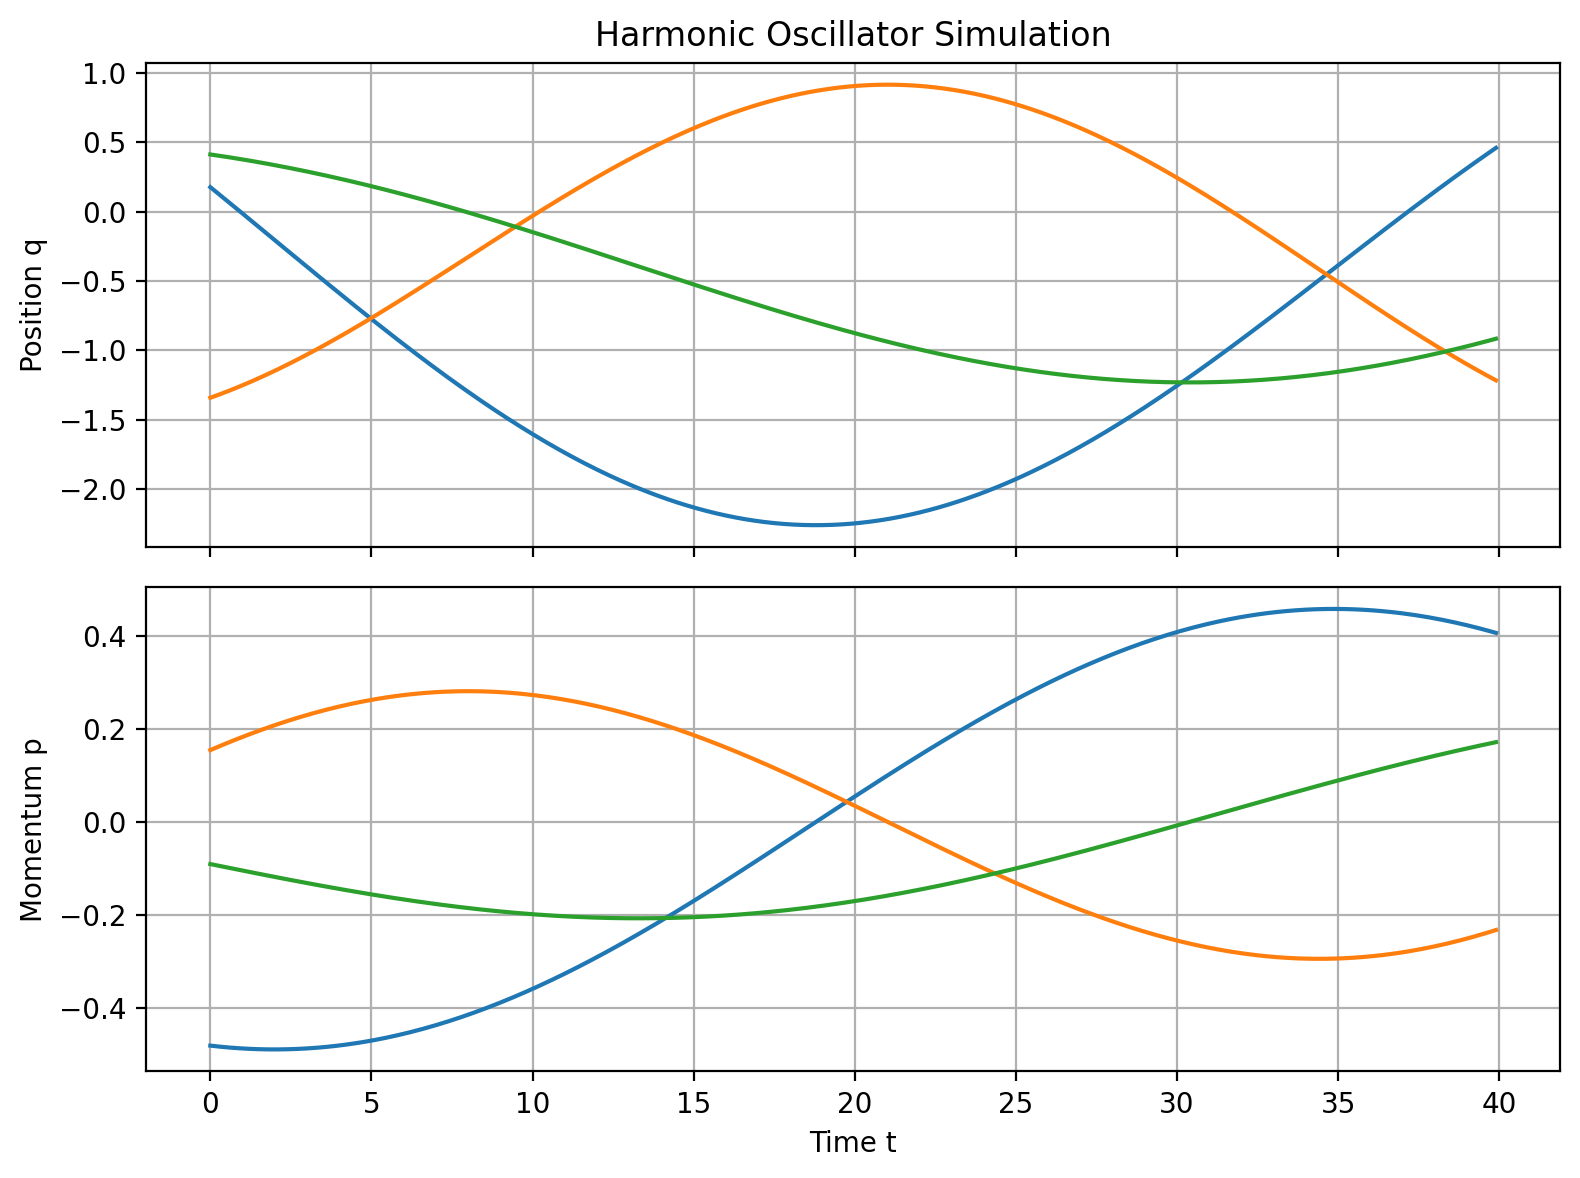

In [60]:
from matplotlib import pyplot as plt

# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [61]:
# t, q, p は前セルのシミュレーション出力。q, p の shape は (T, n)
T, n = q.shape
assert p.shape == (T, n)
dt = float(t[1] - t[0])

# 時系列で分割（情報漏洩を防ぐため、時間で切る）
frac_train = 0.6
frac_test  = 0.3
T_train = int(T * frac_train)
T_test  = int(T * frac_test)

q_train = jnp.asarray(q[:T_train])
p_train = jnp.asarray(p[:T_train])

q_test  = jnp.asarray(q[-T_test:])
p_test  = jnp.asarray(p[-T_test:])

# 時刻ずらしペアを作成
def make_pairs(q_arr, p_arr, jump: int):
    # 返り値 shape: (N, n) 同士の対応
    return (
        q_arr[:-jump], p_arr[:-jump],
        q_arr[jump:],  p_arr[jump:]
    )

jump = 10  # 例：10 ステップ先
train_curr_q, train_curr_p, train_tgt_q, train_tgt_p = make_pairs(q_train, p_train, jump)
test_curr_q,  test_curr_p,  test_tgt_q,  test_tgt_p  = make_pairs(q_test,  p_test,  jump)

N_train = train_curr_q.shape[0]
N_test  = test_curr_q.shape[0]
print("train pairs:", N_train, "test pairs:", N_test)

# バッチサンプラー
batch_size = 128
rng = jax.random.PRNGKey(0)

def sample_train_batch(rng):
    idx = jax.random.choice(rng, N_train, shape=(min(batch_size, N_train),), replace=False)
    return (
        train_curr_q[idx], train_curr_p[idx],
        train_tgt_q[idx],  train_tgt_p[idx],
    )


train pairs: 230 test pairs: 110


In [62]:
rng, sub = jax.random.split(rng)
batch = sample_train_batch(sub)
print(batch.shape)

AttributeError: 'tuple' object has no attribute 'shape'

In [63]:
batch[0].shape

(128, 3)

## G-Symp Net and Action Angle Network
Daigavane et al, 2022にあるブロック
\begin{equation}
f(x)=C x+W^T \operatorname{diag}(A) \sigma(W x+B)
\end{equation}

In [64]:
class GSBlock(nn.Module):
    dim_config: int # dimenion of configuration space
    dim_hidden: int # hidden dimension of MLP
    activation: Callable = nn.relu 

    def setup(self):

        #self.W_affine = nn.Dense(self.dim_hidden, name="W_affine")
        self.W_affine = self.param("W_affine", nn.initializers.lecun_normal(),
                                    (self.dim_config, self.dim_hidden))
        self.B_bias = self.param("B_bias", nn.initializers.zeros, (self.dim_hidden,))
        self.A_diag = self.param("A_diag", nn.initializers.ones, (self.dim_hidden,))
        self.C_lin = nn.Dense(self.dim_config, use_bias=False, name="C_lin")

    @nn.compact
    def __call__(self, x):
        # x: (B, dim_config)
        y = self.activation(x @ self.W_affine + self.B_bias) # (B, dim_hidden)
        z = (y * self.A_diag) @ self.W_affine.T 
        # (B, dim_hidden) ⊙ (dim_hidden,) -> (B, dim_hidden) -> (B, dim_config)

        # # (B, dim_config) -> (B, dim_hidden)
        # y = self.activation(self.W_affine(x))
        # # W_affine の kernel を取得（形状は (dim_hidden, dim_config) ※Flax Dense の慣習）
        # # z = (A ⊙ y) @ W   だが kernel は (d, m) なので転置して (m, d)
        # W_kernel = self.variables["params"]["W_affine"]["kernel"]  # (dim_hidden, dim_config)
        # z = (y * self.A_diag) @ W_kernel.T # (B, dim_config)

        return z + self.C_lin(x) # (B, dim_config)

class GSympNet(nn.Module):
    dim_config: int # dimenion of configuration space
    dim_hidden: int # hidden dimension of MLP
    num_blocks: int
    block_fcn: Callable = GSBlock # fucntion to generate block
    activation: Callable = nn.relu    

    def setup(self):
        assert self.num_blocks % 2 == 0, "num_blocks must be even number"
        self.blocks =[
            self.block_fcn(
                dim_config=self.dim_config,
                dim_hidden=self.dim_hidden,
                activation=self.activation,
                name=f'gsblock_{i}'
                ) for i in range(self.num_blocks)
        ]

    def __call__(self, q, p):
        for idx, blk in enumerate(self.blocks):
            if idx % 2 == 0:
                p = p + blk(q)
            else:
                q = q + blk(p)
        return q, p # I^x, I^y
    
    # 逆写像：層を逆順に、加算の符号を反転（可逆三角写像の基本）
    def inverse(self, q, p):
        for idx in reversed(range(self.num_blocks)):
            blk = self.blocks[idx]
            if idx % 2 == 0:           # p' = p + f(q)  =>  p = p' - f(q)
                p = p - blk(q)
            else:                    # q' = q + f(p)  =>  q = q' - f(p)
                q = q - blk(p)
        return q, p

class PolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, Ix, Iy):
        I = jnp.sqrt(Ix**2 + Iy**2)
        theta = jnp.arctan2(Iy, Ix)
        return I, theta

class GotosCanonicalPolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, Ix, Iy):
        I = 0.5 * (Ix**2 + Iy**2)
        theta = jnp.arctan2(-Iy, Ix)
        return I, theta

class InversePolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, I, theta):
        Ix = jnp.sqrt(I) * jnp.cos(theta)
        Iy = jnp.sqrt(I) * jnp.sin(theta)
        return Ix, Iy

class InverseGotosCanonicalPolarCoordinates(nn.Module):
    dim_config: int # dimenion of configuration space

    def setup(self):
        pass

    def __call__(self, I, theta):
        Ix = jnp.sqrt(2*I) * jnp.cos(theta)
        Iy = -jnp.sqrt(2*I) * jnp.sin(theta)
        return Ix, Iy

class MLP(nn.Module):
    dim_input: int
    dim_output: int
    dim_hidden: int
    activation: Callable = nn.relu
    
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.dim_hidden)(x)
        x = self.activation(x)
        x = nn.Dense(self.dim_output)(x)
        return x

class MyActionAngleNetwork(nn.Module):
    dim_config: int # dimenion of configuration space
    dim_hidden: int # hidden dimension of MLP
    num_gsblocks: int
    type_polar: str = "canonical" # "canonical" or "normal"
    activation: Callable = nn.relu

    def setup(self):
        self.gsymp_net = GSympNet(
            dim_config=self.dim_config,
            dim_hidden=self.dim_hidden,
            num_blocks=self.num_gsblocks,
            activation=self.activation
        )
        if self.type_polar == "normal":
            self.to_polar = PolarCoordinates(dim_config=self.dim_config)
            self.inv_polar = InversePolarCoordinates(dim_config=self.dim_config)
        elif self.type_polar == "canonical":
            self.to_polar = GotosCanonicalPolarCoordinates(dim_config=self.dim_config)
            self.inv_polar = InverseGotosCanonicalPolarCoordinates(dim_config=self.dim_config)
        self.theta_generator = MLP(
            dim_input=self.dim_config,
            dim_output=self.dim_config,
            dim_hidden=self.dim_hidden,
            activation=self.activation
        )
        # self.to_polar = PolarCoordinates(dim_config=self.dim_config)
        # self.to_canonical_polar = GotosCanonicalPolarCoordinates(dim_config=self.dim_config)
        # self.inv_to_polar = InversePolarCoordinates(dim_config=self.dim_config)
        # self.inv_to_canonical_polar = InverseGotosCanonicalPolarCoordinates(dim_config=self.dim_config)

    def __call__(self, q, p, delta_t, train: bool = True):
        # (q, p) -> (Ix, Iy)
        Ix, Iy = self.gsymp_net(q, p)

        # (Ix, Iy) -> (I, theta)
        I, theta = self.to_polar(Ix, Iy)

        # I_ = I as I should be constant, only renew theta
        theta_ = theta + delta_t * self.theta_generator(I)

        # inverse from future: (Ix_, Iy_) -> (q_, p_)
        Ix_, Iy_ = self.inv_polar(I, theta_)
        q_, p_ = self.gsymp_net.inverse(Ix_, Iy_)

        return q_, p_, I, theta


# Create model & Train

In [65]:

model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden=64,
    num_gsblocks=4,
    type_polar="canonical",
    activation=nn.relu
)


In [66]:
q0 = train_curr_q[:1]
p0 = train_curr_p[:1]
delta_t_scalar = jnp.asarray(dt * jump)  # スカラー


In [67]:
q0.shape

(1, 3)

In [68]:


@jit
def train_step(params, opt_state, x, y, delta_t, alpha, key):
    T = x.shape[0]
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)

    def loss_fn(pp):
        q_, p_, I, _ = model.apply({'params': pp}, q, p, delta_t, train=True, rngs={'noise': key})
        #x_ = jnp.concatenate([q_, p_], axis=-1)
        
        # prediction loss
        loss_q_se = ((q_ - y[:, :n]) ** 2).sum()
        loss_p_se = ((p_ - y[:, n:]) ** 2).sum()

        # actions should be constant
        loss_action = jnp.var(I, axis=0).sum()

        return loss_q_se + loss_p_se + alpha * loss_action

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@jit
def eval_batch(params, x, y, delta_t, key):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)
    
    q_, p_, _, _ = model.apply({'params': params}, q, p, delta_t, train=True, rngs={'noise': key})
    #x_ = jnp.concatenate([q_, p_], axis=-1)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [69]:

wandb.login()  # すでに環境変数 WANDB_API_KEY があれば不要


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

In [70]:
key = random.PRNGKey(0)
eval_key  = random.PRNGKey(42)


In [71]:

run = wandb.init(
    project="aan_scratch_harm_osc",
    name="aan_scratch_test_harm_osc",
    config={
            "model": "MyActionAngleNetwork",
            "num_gsblocks": 4,
            "dim_hidden": 64,
            "type_polar": "canonical",
            "activation": "relu",
            "T": 400,
            "dt": 0.1,
            "n": 3,
            "opt": dict(optimizer="adamw", lr=3e-4, weight_decay=1e-4, grad_clip=1.0),
            "rng": dict(train_seed=int(key[0]), eval_seed=int(eval_key[0])),
        },
)
                    
                 

In [72]:

params = model.init(rng, q0, p0, delta_t_scalar)["params"]

# オプティマイザ
tx = optax.adam(1e-3)
opt_state = tx.init(params)

In [73]:
num_steps = 2000
log_every = 100

alpha = 0.1  # weight for action constancy loss

delta_t_scalar = jnp.asarray(dt * jump)

for step in range(1, num_steps + 1):
    rng, sub = jax.random.split(rng)
    batch = sample_train_batch(sub)

    params, opt_state, train_loss = train_step(
        params=params, opt_state=opt_state, x=batch[0], y=batch[1], alpha=alpha, delta_t=delta_t_scalar,key=rng)

    if step % log_every == 0 or step == 1:
        test_loss = eval_batch(
            params=params,
            x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
            y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
            delta_t=delta_t_scalar,
            key=eval_key
        )
        # test_loss = eval_batch(
        #     params, test_curr_q, test_curr_p, test_tgt_q, test_tgt_p, delta_t_scalar
        # )
        print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss {float(test_loss):.6f}")
        wandb.log({
            "train/loss": float(train_loss),
            "test/loss": float(test_loss),
            "step": step,
        })

TypeError: dot_general requires contracting dimensions to have the same shape, got (1,) and (3,).

In [ ]:

# # ===== 学習ループ =====
# tx = optax.chain(
#     optax.clip_by_global_norm(1.0),   # ← これを足すだけで全然違う
#     optax.adamw(3e-4, weight_decay=1e-4),
# )
# opt_state = tx.init(params)


# def count_params(params):
#     sizes = [np.prod(p.shape) for p in jax.tree_util.tree_leaves(params)]
#     return int(sum(sizes))

# wandb.config.update({"num_params": count_params(params)}, allow_val_change=True)


# # ===== 学習ループ =====
# EPOCHS = 5
# for epoch in range(1, EPOCHS+1):
#     t0 = time.time()
#     # Train
#     running, n = 0.0, 0
#     for x, y in train_loader:
#         key, sub = random.split(key)
#         x = jnp.asarray(x)
#         y = jnp.asarray(y)
#         params, opt_state, loss = step(params, opt_state, x, y, sub)
#         running += float(loss) * x.shape[0]
#         n += x.shape[0]
#     train_loss = running / max(1,n)

#     # Valid
#     corr, n = 0.0, 0
#     for x, y in valid_loader:
#         acc = float(eval_batch(params, jnp.asarray(x), jnp.asarray(y), eval_key))
#         corr += acc * x.shape[0]
#         n += x.shape[0]
#     val_acc = corr / n
#     dt = time.time() - t0
    
#     print(f"Epoch {epoch}/{EPOCHS}  loss={train_loss:.4f}  val_acc={val_acc:.4f}")

#     # ---- wandb にログ（エポック単位）----
#     wandb.log(
#         {"train/loss": train_loss, "valid/acc": val_acc, "time/epoch_sec": dt},
#         step=epoch
#     )

